# Test

手动指定模型权重和测试集 CSV，执行测试集预测，计算二分类评价指标，并绘制核心可视化。


## 1. 环境准备

In [1]:
import sys
import os
import math
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    brier_score_loss,
    log_loss,
    roc_curve,
    precision_recall_curve,
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from matplotlib.colors import LinearSegmentedColormap

# 项目根目录
ROOT = Path('/home/xuyzh/d2l/SYSU-hw/MutDisease')
sys.path.insert(0, str(ROOT / 'script'))

from dataloader import MissenseDataset, MissenseCollator
from model import MissenseESMBiLSTM, MLPClassifier, CNNPairClassifier, GatedResidualClassifier
from aaindex import AAINDEX_DIM

# 设备与随机种子
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print('Device:', device)


Device: cuda


## 2. 模型权重与测试集路径




In [3]:
# 手动填写：模型权重和测试集 CSV
MODEL_PATH = '/home/xuyzh/d2l/SYSU-hw/MutDisease/model/mlp_exp9_final.pt'
TEST_CSV = '/home/xuyzh/d2l/SYSU-hw/MutDisease/data/proceed/splits/test.csv'

# 推理参数
BATCH_SIZE = 32
NUM_WORKERS = 2

MODEL_PATH = Path(MODEL_PATH)
TEST_CSV = Path(TEST_CSV)

assert MODEL_PATH.exists(), f'Model checkpoint not found: {MODEL_PATH}'
assert TEST_CSV.exists(), f'Test CSV not found: {TEST_CSV}'

print('Model checkpoint:', MODEL_PATH)
print('Test CSV        :', TEST_CSV)


Model checkpoint: /home/xuyzh/d2l/SYSU-hw/MutDisease/model/mlp_exp9_final.pt
Test CSV        : /home/xuyzh/d2l/SYSU-hw/MutDisease/data/proceed/splits/test.csv


## 3. Model load

根据 checkpoint 中保存的 `config` 自动重建对应架构，并加载权重。

In [4]:
def build_classifier(input_dim, classifier_type, proj_dim, dropout):
    hidden_dim = max(proj_dim // 2, 64)
    if classifier_type == 'mlp':
        return MLPClassifier(input_dim, hidden_dim, dropout)
    if classifier_type == 'cnn':
        return CNNPairClassifier(input_dim, hidden_dim, dropout)
    if classifier_type == 'gated':
        return GatedResidualClassifier(input_dim, hidden_dim, dropout)
    raise ValueError(f'Unsupported classifier: {classifier_type}')


def load_model(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg = ckpt.get('config', {})
    print('Checkpoint config:')
    for k, v in cfg.items():
        print(f'  {k}: {v}')

    classifier_type = cfg.get('classifier_type', 'mlp')
    proj_dim = cfg.get('proj_dim', 64)
    dropout = cfg.get('dropout', 0.5)
    lstm_hidden = cfg.get('lstm_hidden', 256)
    plm_name = cfg.get('plm_name', 'facebook/esm2_t33_650M_UR50D')
    freeze_esm = cfg.get('freeze_esm', True)

    classifier = build_classifier(proj_dim * 4, classifier_type, proj_dim, dropout)
    model = MissenseESMBiLSTM(
        plm_name=plm_name,
        aaindex_dim=AAINDEX_DIM,
        lstm_hidden=lstm_hidden,
        proj_dim=proj_dim,
        dropout=dropout,
        freeze_esm=freeze_esm,
        local_files_only=True,
        classifier=classifier,
    ).to(device)

    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, cfg


model, cfg = load_model(MODEL_PATH, device)


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Checkpoint config:
  tag: exp9_final
  classifier_type: mlp
  plm_name: facebook/esm2_t33_650M_UR50D
  epochs: 15
  batch_size: 32
  lr: 6.481308012346065e-05
  weight_decay: 0.005135321670338704
  lstm_hidden: 256
  proj_dim: 64
  dropout: 0.5382680063323042
  freeze_esm: True
  threshold: 0.5


## 4. 构建测试集 DataLoader

In [6]:
def get_test_loader(csv_path, plm_name, batch_size=32, num_workers=2):
    dataset = MissenseDataset(csv_path)
    collator = MissenseCollator(plm_name, local_files_only=True)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=collator,
        pin_memory=torch.cuda.is_available(),
    )


test_loader = get_test_loader(
    TEST_CSV,
    cfg.get('plm_name', 'facebook/esm2_t33_650M_UR50D'),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
print(f'Test samples: {len(test_loader.dataset)}, batches: {len(test_loader)}')


Test samples: 5000, batches: 157


## 5. Predict

In [7]:
def move_batch(batch, device):
    return {k: v.to(device) if hasattr(v, 'to') else v for k, v in batch.items()}


def predict(model, loader, device):
    model.eval()
    labels, probs = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Predicting'):
            batch = move_batch(batch, device)
            logits = model(batch)
            probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())
            labels.extend(batch['labels'].cpu().numpy().tolist())
    return np.array(labels), np.array(probs)


labels, probs = predict(model, test_loader, device)
print(f'Collected {len(labels)} predictions')


Predicting:   0%|          | 0/157 [00:00<?, ?it/s]

Collected 5000 predictions


## 6. 计算并打印指标

In [8]:
THRESHOLD = cfg.get('threshold', 0.5)


def calc_metrics(labels, probs, threshold=0.5):
    labels = labels.astype(int)
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()

    eps = 1e-12
    clipped_probs = np.clip(probs, eps, 1 - eps)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    metrics = {
        'AUROC': roc_auc_score(labels, probs),
        'AUPRC': average_precision_score(labels, probs),
        'Accuracy': accuracy_score(labels, preds),
        'Balanced Accuracy': balanced_accuracy_score(labels, preds),
        'Precision/PPV': precision_score(labels, preds, zero_division=0),
        'Recall/Sensitivity': recall_score(labels, preds, zero_division=0),
        'Specificity': specificity,
        'NPV': npv,
        'F1': f1_score(labels, preds, zero_division=0),
        'MCC': matthews_corrcoef(labels, preds),
        'FPR': fpr,
        'FNR': fnr,
        'Brier Score': brier_score_loss(labels, probs),
        'Log Loss': log_loss(labels, clipped_probs),
    }
    counts = {
        'TP': int(tp),
        'FP': int(fp),
        'TN': int(tn),
        'FN': int(fn),
        'Positive Support': int(labels.sum()),
        'Negative Support': int((labels == 0).sum()),
    }
    return metrics, counts


metrics, counts = calc_metrics(labels, probs, threshold=THRESHOLD)
print(f'Threshold = {THRESHOLD}')
print('\nMetrics:')
for k, v in metrics.items():
    print(f'{k:20s}: {v:.4f}')
print('\nConfusion counts:')
for k, v in counts.items():
    print(f'{k:20s}: {v}')


Threshold = 0.5

Metrics:
AUROC               : 0.8885
AUPRC               : 0.8894
Accuracy            : 0.8080
Balanced Accuracy   : 0.8080
Precision/PPV       : 0.8522
Recall/Sensitivity  : 0.7452
Specificity         : 0.8708
NPV                 : 0.7736
F1                  : 0.7951
MCC                 : 0.6209
FPR                 : 0.1292
FNR                 : 0.2548
Brier Score         : 0.1419
Log Loss            : 0.4735

Confusion counts:
TP                  : 1863
FP                  : 323
TN                  : 2177
FN                  : 637
Positive Support    : 2500
Negative Support    : 2500


## 7. 可视化

配色：
- `#780000` 深红
- `#c1121f` 亮红
- `#fdf0d5` 米白
- `#003049` 深蓝
- `#669bbc` 灰蓝

In [ ]:
# 定义项目配色
COLORS = ['d9ed92', '99d98c', '76c893', '34a0a4', '1e6091', '184e77']
COLORS = [c if c.startswith('#') else f'#{c}' for c in COLORS]

# 设置 seaborn / matplotlib 风格
sns.set_theme(style='whitegrid', palette=COLORS)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.labelcolor'] = COLORS[3]
plt.rcParams['xtick.color'] = COLORS[3]
plt.rcParams['ytick.color'] = COLORS[3]
plt.rcParams['text.color'] = COLORS[3]


### 7.1 metric




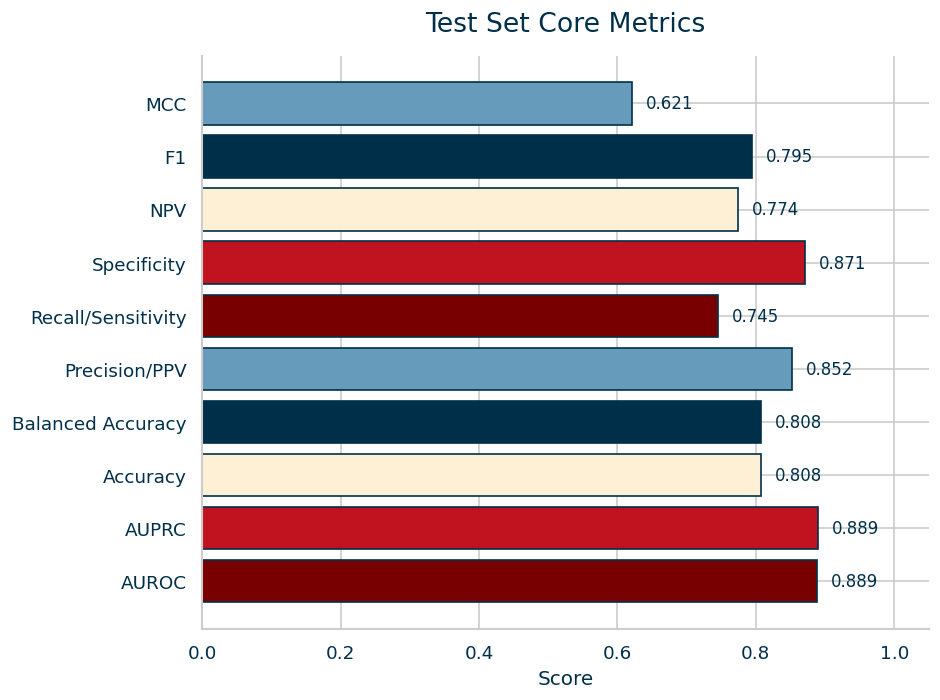

In [11]:
PLOT_METRICS = [
    'AUROC',
    'AUPRC',
    'Accuracy',
    'Balanced Accuracy',
    'Precision/PPV',
    'Recall/Sensitivity',
    'Specificity',
    'NPV',
    'F1',
    'MCC',
]

fig, ax = plt.subplots(figsize=(8, 6))

names = PLOT_METRICS
values = [metrics[name] for name in names]
bars = ax.barh(
    names,
    values,
    color=[COLORS[i % len(COLORS)] for i in range(len(names))],
    edgecolor=COLORS[3],
)

ax.set_xlim(0, 1.05)
ax.set_title('Test Set Core Metrics', fontsize=16, color=COLORS[3], pad=15)
ax.set_xlabel('Score', fontsize=12)

for bar, val in zip(bars, values):
    ax.text(
        min(val + 0.02, 1.01),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center',
        color=COLORS[3],
        fontsize=10,
    )

sns.despine()
plt.tight_layout()
plt.show()


### 7.2 混淆矩阵

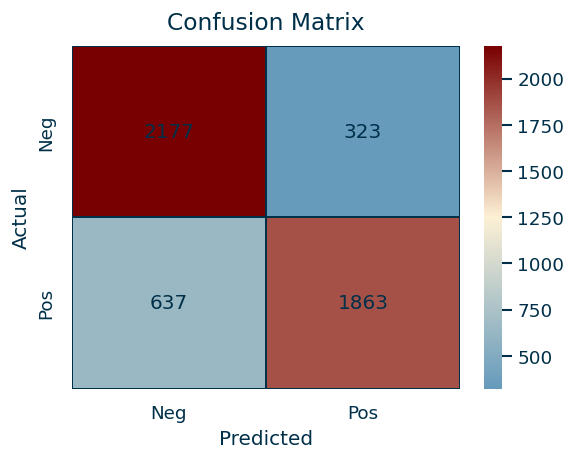

In [12]:
cm = confusion_matrix(labels, (probs >= THRESHOLD).astype(int))
cmap = LinearSegmentedColormap.from_list('custom', [COLORS[4], COLORS[2], COLORS[0]])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=cmap,
    ax=ax,
    xticklabels=['Neg', 'Pos'],
    yticklabels=['Neg', 'Pos'],
    annot_kws={'color': COLORS[3], 'fontsize': 12},
    linewidths=1,
    linecolor=COLORS[3],
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, pad=10)
plt.tight_layout()
plt.show()


### 7.3 ROC 曲线与 PR 曲线

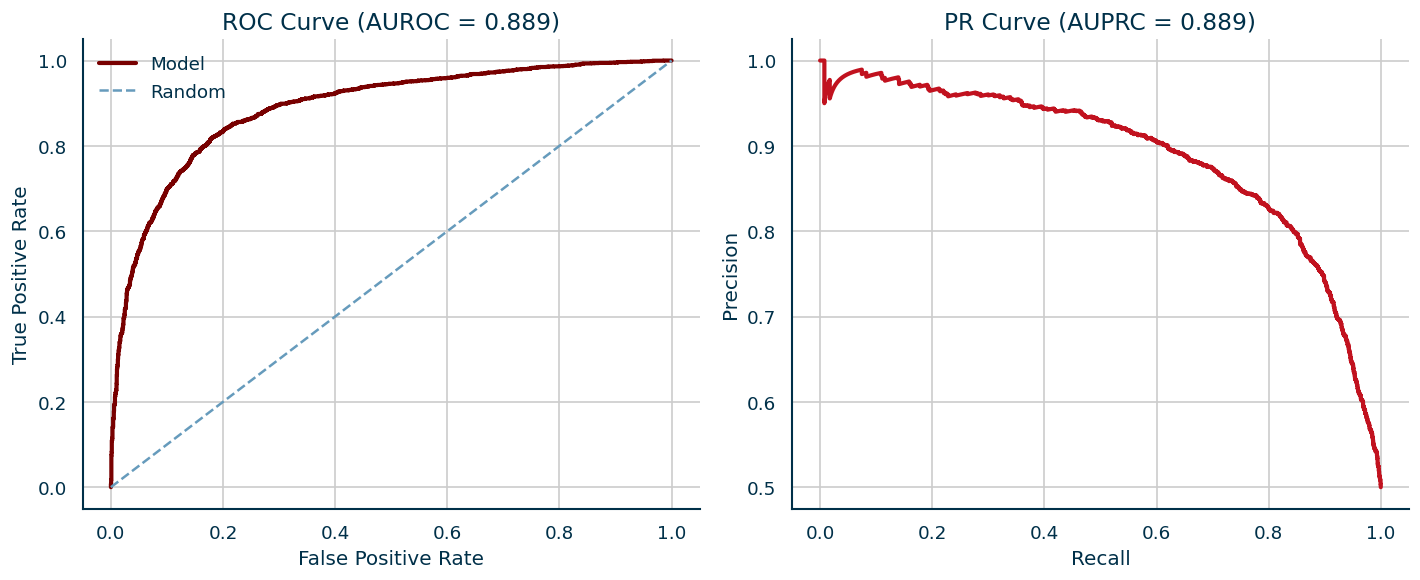

In [13]:
fpr, tpr, _ = roc_curve(labels, probs)
precision_curve, recall_curve, _ = precision_recall_curve(labels, probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(fpr, tpr, color=COLORS[0], lw=2.5, label='Model')
axes[0].plot([0, 1], [0, 1], color=COLORS[4], linestyle='--', lw=1.5, label='Random')
axes[0].set_title(f'ROC Curve (AUROC = {metrics["AUROC"]:.3f})', fontsize=14)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(frameon=False)

# PR
axes[1].plot(recall_curve, precision_curve, color=COLORS[1], lw=2.5)
axes[1].set_title(f'PR Curve (AUPRC = {metrics["AUPRC"]:.3f})', fontsize=14)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')

for ax in axes:
    ax.spines['bottom'].set_color(COLORS[3])
    ax.spines['left'].set_color(COLORS[3])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors=COLORS[3])

plt.tight_layout()
plt.show()
